# Step 1. 인물모드 직접 해 보기

In [1]:
import cv2
import numpy as np
import torch
import torchvision.transforms as T
from torchvision.models.segmentation import deeplabv3_resnet101
import matplotlib.pyplot as plt

print(cv2.__version__)

4.11.0


원본 고양이 이미지 크기: (4640, 6960, 3)
배경(사막) 이미지 크기: (1366, 2048, 3)
원본 인물 이미지 크기: (5568, 3712, 3)


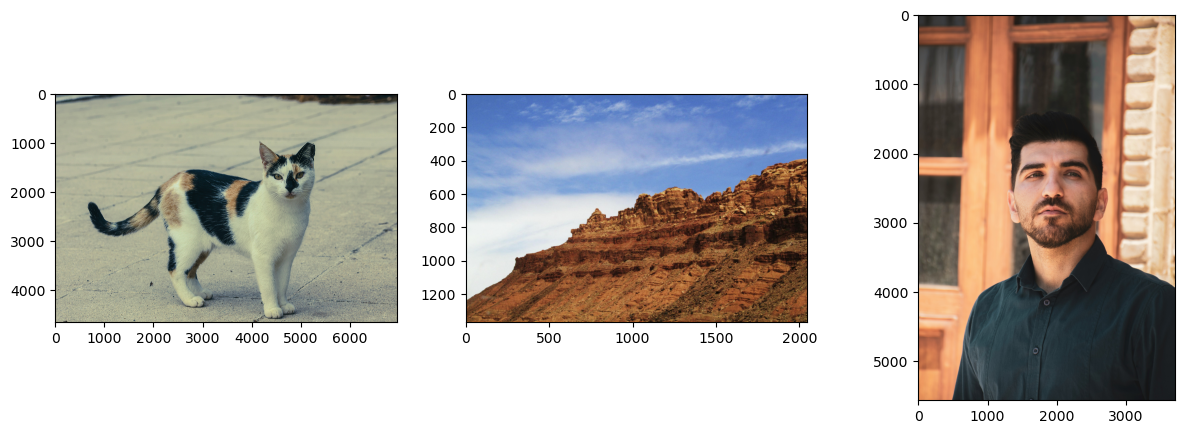

In [16]:
cat_img_path = "cat.jpg"  # 고양이 이미지를 준비해주세요
sand_img_path = "sand.jpg"  # 사막 배경 이미지를 준비해주세요
person_img_path = "person.jpg"

cat_img = cv2.imread(cat_img_path)
sand_img = cv2.imread(sand_img_path)
person_img = cv2.imread(person_img_path)

cat_img = cv2.cvtColor(cat_img, cv2.COLOR_BGR2RGB)
sand_img = cv2.cvtColor(sand_img, cv2.COLOR_BGR2RGB)
person_img = cv2.cvtColor(person_img, cv2.COLOR_BGR2RGB)

print(f"원본 고양이 이미지 크기: {cat_img.shape}")
print(f"배경(사막) 이미지 크기: {sand_img.shape}")
print(f"원본 인물 이미지 크기: {person_img.shape}")

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(cat_img)

plt.subplot(1, 3, 2)
plt.imshow(sand_img)

plt.subplot(1, 3, 3)
plt.imshow(person_img)

plt.show()

In [17]:
model = deeplabv3_resnet101(pretrained=True).eval()

transform = T.Compose([
    T.ToPILImage(),
    T.Resize((520, 520)),  # 모델 입력 크기
    T.ToTensor(),
])

# 고양이 이미지 추론
input_tensor = transform(cat_img).unsqueeze(0)

with torch.no_grad():
    output = model(input_tensor)["out"][0]
    output_predictions = output.argmax(0).byte().cpu().numpy()

print(f"추론 마스크 크기 (Before Resize): {output_predictions.shape}")

# 인물 이미지 추론
person_input_tensor = transform(person_img).unsqueeze(0)

with torch.no_grad():
    person_output = model(person_input_tensor)["out"][0]
    person_output_predictions = person_output.argmax(0).byte().cpu().numpy()

print(f"인물 추론 마스크 크기 (Before Resize): {person_output_predictions.shape}")

추론 마스크 크기 (Before Resize): (520, 520)
인물 추론 마스크 크기 (Before Resize): (520, 520)


In [18]:
# 고양이 마스크를 원본 크기로 Resize
output_predictions_resized = cv2.resize(output_predictions, (cat_img.shape[1], cat_img.shape[0]), interpolation=cv2.INTER_NEAREST)

print(f"추론 마스크 크기 (After Resize): {output_predictions_resized.shape}")

# 인물 마스크를 원본 크기로 Resize
person_output_predictions_resized = cv2.resize(
    person_output_predictions,
    (person_img.shape[1], person_img.shape[0]),
    interpolation=cv2.INTER_NEAREST
)

print(f"인물 추론 마스크 크기 (After Resize): {person_output_predictions_resized.shape}")

추론 마스크 크기 (After Resize): (4640, 6960)
인물 추론 마스크 크기 (After Resize): (5568, 3712)


In [19]:
cat_unique_classes = np.unique(output_predictions_resized)
print(f"고양이 예측된 클래스 ID: {cat_unique_classes}")

person_unique_classes = np.unique(person_output_predictions_resized)
print(f"인물 예측된 클래스 ID: {person_unique_classes}")



고양이 예측된 클래스 ID: [0 8]
인물 예측된 클래스 ID: [ 0 15]


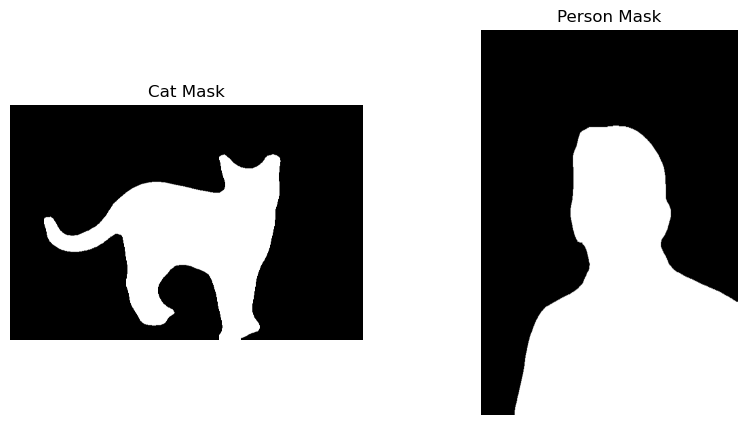

In [20]:
cat_class_id = 8
person_class_id = 15

# 고양이 마스크
cat_seg_map = (output_predictions_resized == cat_class_id)
img_mask = cat_seg_map.astype(np.uint8) * 255

# 인물 마스크
person_seg_map = (person_output_predictions_resized == person_class_id)
person_mask = person_seg_map.astype(np.uint8) * 255

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.title("Cat Mask")
plt.imshow(img_mask, cmap="gray")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Person Mask")
plt.imshow(person_mask, cmap="gray")
plt.axis("off")

plt.show()

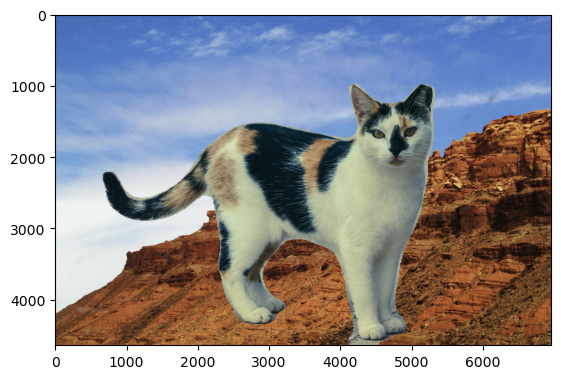

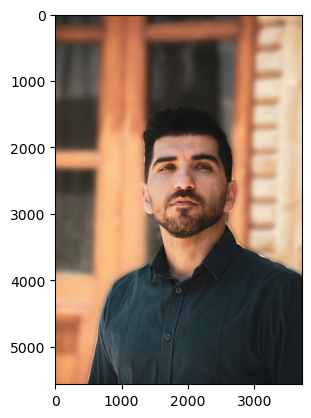

In [23]:
# 배경을 고양이 이미지 크기에 맞춤
sand_img_resized = cv2.resize(sand_img, (cat_img.shape[1], cat_img.shape[0]))

# 고양이 부분만 남기고 배경 적용
img_mask_color = cv2.cvtColor(img_mask, cv2.COLOR_GRAY2BGR)  # 3채널 변환
result_img = np.where(img_mask_color == 255, cat_img, sand_img_resized)  # 마스크 기반 합성

plt.imshow(result_img)
plt.show()

# 인물모드 아웃포커싱
person_blur = cv2.GaussianBlur(person_img, (251, 251), 0)
person_mask_color = cv2.cvtColor(person_mask, cv2.COLOR_GRAY2RGB)

person_outfocus = np.where(person_mask_color == 255, person_img, person_blur)

plt.imshow(person_outfocus)
plt.show()

# Step 2. 사진에서 문제점 찾기
두 사진 모두 공통적으로 경계면이 부자연스럽다. 

# Step 3. 해결 방법 제안

## 1. 문제 정의
경계면이 부자연스럽다.

## 2. 분해
경계가 부자연스럽다는 문제를 더 작은 문제로 나누어 보았다.

- 고양이 사진에서는 외곽 경계에 흰 테두리가 보이고, 털 끝이 자연스럽게 남지 않아 경계가 잘린 것처럼 보인다.
- 인물 사진에서는 머리카락 끝부분이 배경과 부드럽게 이어지지 않아 머리카락이 붕 뜬 것처럼 보인다. 

## 3. 패턴 인식
두 결과를 비교해 보면, 오류는 공통적으로 피사체의 외곽선 중에서도 털 끝이나 머리카락 끝처럼 얇고 복잡한 경계 부분에서 나타났다.

## 4. 추상화
즉 문제의 본질은 특정 사진의 문제가 아니라, semantic segmentation mask가 털이나 머리카락처럼 복잡한 경계 영역을 충분히 정밀하게 분리하지 못했다는 점이다.

## 5. 알고리즘 설계
현재 방식은 semantic segmentation mask만을 사용하기 때문에 털 끝이나 머리카락 끝처럼 복잡한 경계에서 오류가 발생할 수 있다. 이를 개선하기 위해 semantic segmentation 결과에 depth 정보를 추가로 활용할 수 있다. depth 정보는 피사체와 배경의 거리 차이를 반영할 수 있기 때문에, 처음 생성된 mask를 더 자연스럽게 보완하는 데 도움이 된다. 이렇게 보완된 mask를 사용해 blur 또는 배경 합성을 수행하면 외곽선의 흰 테두리나 붕 뜬 느낌을 줄일 수 있다.